# Federated vs Centralized Training Comparison

This notebook demonstrates a comparison between **Federated Learning (FL)** and **Centralized Training** for a binary classification task using PyTorch.

The routines here are condensed for clarity but preserve full functionality:
- **Federated Training**: Clients train locally and share model weights for aggregation via `FedAvg`.
- **Centralized Training**: A single model is trained on all combined data as a baseline.
- **Evaluation Metrics**: F1-score, precision, recall, and loss are logged and visualized.

---


## Imports

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [2]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [3]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [4]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [5]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


# Example: Instantiate the model
model = GenerateModel(table_path=os.path.join("..", "Model", "processed_full.w2v")).to(device)
model

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (embed_drop): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
)

## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [6]:
# FedAvg - working with parameter dictionary rather than deepcopy

def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.

    Args:
        global_model (dict): Global model parameter dictionary (in-place update).
        client_state_dicts (list[dict]): List of parameter dictionaries from clients.

    Returns:
        dict: Updated global parameter dictionary (averaged across clients).
    """
    for key in global_model.keys():
        # Stack corresponding parameters from all clients and take mean
        stacked = torch.stack(
            [client_dict[key].float() for client_dict in client_state_dicts],
            dim=0
        )
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [ ]:
# === FedProx (adds proximal term) ===
def FedProx_update(model, global_params, mu=0.01):
    """
    Compute the FedProx proximal term.
    Args:
        model: Local model (nn.Module)
        global_params: Global model parameters (Iterable[Tensor])
        mu: Regularization strength (float)
    Returns:
        torch.Tensor: Proximal regularization loss term
    """
    prox_loss = 0.0
    for p, g in zip(model.parameters(), global_params):
        prox_loss += ((p - g.detach()) ** 2).sum()
    return mu / 2 * prox_loss

In [ ]:
# === SCAFFOLD (with control variates) ===
class ScaffoldController:
    """
    Implements SCAFFOLD correction using control variates.
    Tracks c_global and each client's c_local.
    """
    def __init__(self, model):
        # initialize control variates for global and each client
        self.c_global = {k: torch.zeros_like(v) for k, v in model.state_dict().items()}
        self.c_local = {}  # {client_id: {param_name: tensor}}

    def init_client(self, client_id, model):
        """Initialize local control variates for a client."""
        self.c_local[client_id] = {k: torch.zeros_like(v) for k, v in model.state_dict().items()}

    def apply_update(self, client_id, model, global_model, lr):
        """
        Apply SCAFFOLD correction to model gradients before local update.
        """
        for (name, param), (name_g, param_g) in zip(model.named_parameters(), global_model.named_parameters()):
            if param.grad is not None:
                param.grad += self.c_global[name_g] - self.c_local[client_id][name]


    def update_controls(self, client_id, old_state, new_state, lr, local_epochs):
        """
        Update both local and global control variates after client training.
        """
        c_local_old = self.c_local[client_id]
        delta_c = {}
        for key in new_state.keys():
            delta_w = new_state[key] - old_state[key]
            delta_c[key] = -(1.0 / (local_epochs * lr)) * delta_w
            c_local_old[key] = c_local_old[key] + delta_c[key] - self.c_global[key]

        # global update = mean of all local updates (to be done on server side)
        return delta_c
    
# Example instantiation (used during training setup)
# scaffold_ctrl = ScaffoldController(Global_Model)
# scaffold_ctrl.init_client(0, Global_Model)

In [7]:
# Example of Fed Averaging

g_param = {
    "layer1": torch.zeros(size=(4, 4))
}

# Simulate 3 clients with random local parameters
c_param = [
    {"layer1": torch.randint(low=0, high=10, size=(4, 4))}
    for _ in range(3)
]

print("🧱 Global Model (Before Aggregation):\n", g_param["layer1"])
print("\nClient Models:")
for i, client in enumerate(c_param, start=1):
    print(f"Client {i}:\n", client["layer1"])

# Perform federated averaging
g_param = FedAvg(global_model=g_param, client_state_dicts=c_param)

print("\n🌐 Global Model (After FedAvg):\n", g_param["layer1"])


🧱 Global Model (Before Aggregation):
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Client Models:
Client 1:
 tensor([[6, 2, 9, 9],
        [2, 5, 2, 6],
        [6, 3, 0, 3],
        [0, 7, 1, 2]])
Client 2:
 tensor([[9, 6, 8, 8],
        [0, 4, 7, 8],
        [7, 9, 0, 5],
        [0, 1, 7, 9]])
Client 3:
 tensor([[8, 3, 4, 3],
        [5, 1, 7, 6],
        [4, 9, 3, 8],
        [0, 4, 6, 9]])

🌐 Global Model (After FedAvg):
 tensor([[7.6667, 3.6667, 7.0000, 6.6667],
        [2.3333, 3.3333, 5.3333, 6.6667],
        [5.6667, 7.0000, 1.0000, 5.3333],
        [0.0000, 4.0000, 4.6667, 6.6667]])


### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [8]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [9]:
# Create focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_term = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


In [ ]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    # --- Added for FedProx / SCAFFOLD ---
    global_model: nn.Module = None,
    use_fedprox: bool = False,
    mu: float = 0.01,
    scaffold_ctrl=None,
    client_id: int = None
) -> tuple[float, dict]:
    """
    Perform local training for a single client.
    Supports:
        - FedAvg (default)
        - FedProx (proximal regularization)
        - SCAFFOLD (control variate correction)
    """
    model.to(device)
    model.train()

    # ---- Compute pos_weight (to handle imbalance) ----
    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    # ---- Optimizer and Loss ----
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # ---- Store initial weights (for SCAFFOLD) ----
    old_state = copy.deepcopy(model.state_dict()) if scaffold_ctrl else None

    # ---- Local Training ----
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            # --- FedProx proximal term ---
            if use_fedprox and global_model is not None:
                loss += FedProx_update(model, global_model.parameters(), mu)

            optimizer.zero_grad()
            loss.backward()

            # --- SCAFFOLD gradient correction ---
            if scaffold_ctrl is not None and client_id is not None:
                scaffold_ctrl.apply_update(client_id, model, global_model, lr)

            optimizer.step()

    # ---- Update SCAFFOLD control variates ----
    if scaffold_ctrl is not None and client_id is not None:
        new_state = copy.deepcopy(model.state_dict())
        scaffold_ctrl.update_controls(client_id, old_state, new_state, lr, epochs)

    return loss.item(), model.state_dict()


In [11]:
# Example of local client update

train_loader = load_data(split="train")

local_loss, local_params = client_update(
    model=model,
    train_loader=train_loader,
    epochs=1,
    device="cpu"
)

print(f"📉 Local Training Loss: {local_loss:.4f}")
print("🔧 Example Parameter (embed.weight):\n", local_params["embed.weight"])


📉 Local Training Loss: 0.8488
🔧 Example Parameter (embed.weight):
 tensor([[ 1.3710e+00, -1.1058e+00,  2.0421e+00,  ..., -2.6081e+00,
          9.1003e-01,  8.2254e-01],
        [ 1.5817e+00, -4.5227e-01,  4.5332e-01,  ...,  1.7618e-01,
          7.6717e-01,  1.1082e+00],
        [ 6.9607e-01,  6.6233e-01, -8.9618e-01,  ..., -4.3699e-01,
          7.8535e-01,  1.9697e+00],
        ...,
        [ 7.2904e-03, -9.4383e-04, -2.5926e-02,  ...,  1.3076e-02,
         -2.7830e-02,  1.5075e-02],
        [ 5.7946e-03,  3.3857e-03,  2.6939e-02,  ..., -1.9374e-02,
          2.0232e-02,  1.2402e-02],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])


## Federated Training — Full Experiment Pipeline

This section coordinates the **federated learning process**:
1. Initializes global and client models.
2. Splits the dataset into client partitions.
3. Iteratively performs:
   - Local training (`client_update`)
   - Model aggregation (`FedAvg`)
   - Periodic evaluation and checkpointing

Metrics are saved incrementally to `../History/logs/metric_history.json`, and the best models (by AUC and F1) are checkpointed.


### Set up

In [ ]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,            #how many times clint will go through its own local dataset each round
    "rounds": 100,           #for centralized, this is the epochs
    "use_focal" : False,
    "gamma" : 2.5,
    "algorithm": "FedAvg",  # choose from: "FedAvg", "FedProx", "SCAFFOLD"
    "mu": 0.01,             # FedProx regularization (only used if algorithm == "FedProx")
}

model_param_path = os.path.join("..", "Model", "processed_full.w2v")

Global train size: torch.Size([6453, 50])
Client 1 size: torch.Size([2130, 50])
Client 2 size: torch.Size([2129, 50])
Client 3 size: torch.Size([2194, 50])


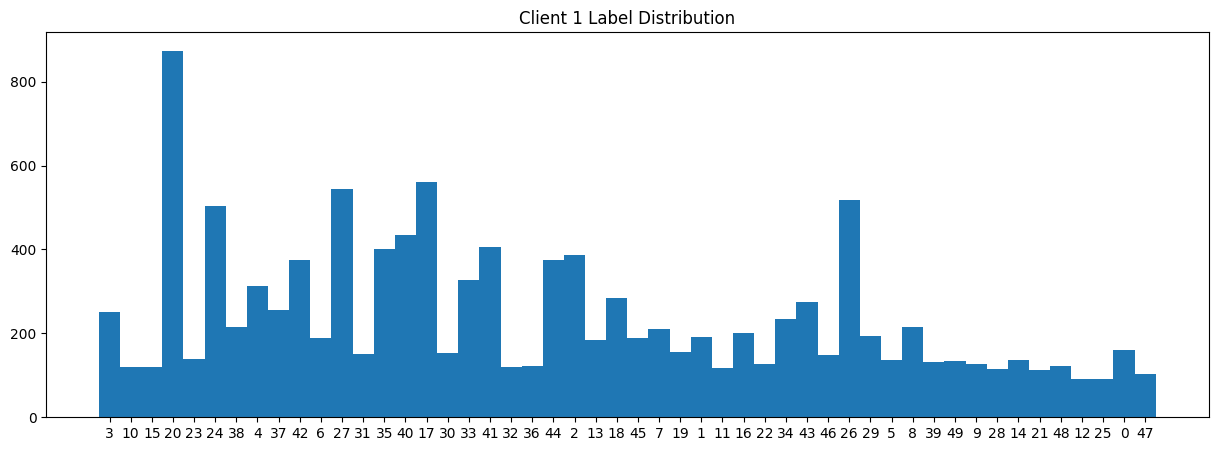

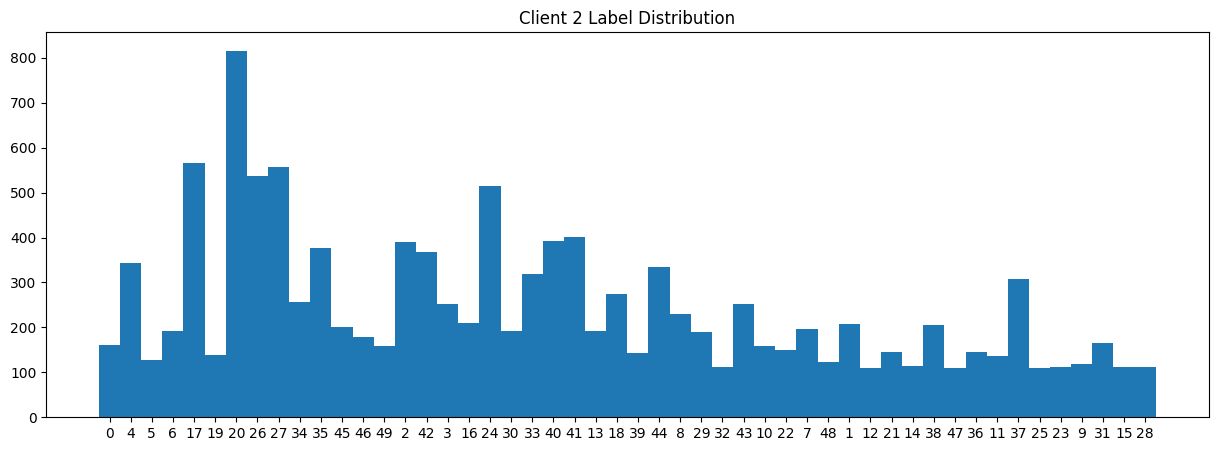

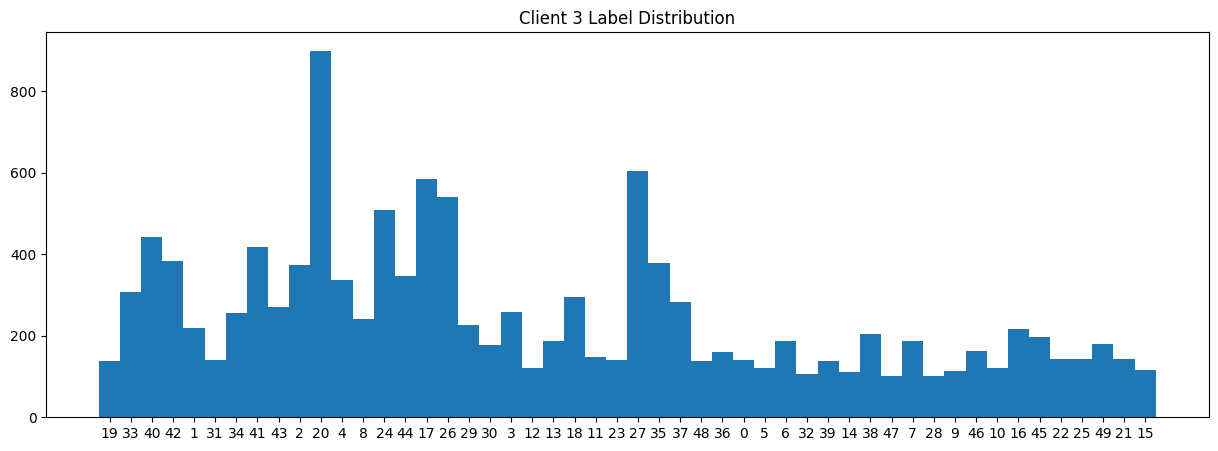

In [13]:
# Client data partitioning

# Load full training data
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

# Split dataset into three clients
c1, c2, c3 = random_split(train_dataset, lengths=[0.33, 0.33, 0.34])
c_loaders = [
    DataLoader(c, batch_size=config["batch_size"], shuffle=True)
    for c in [c1, c2, c3]
]

# Display data distribution
print(f"Global train size: {train_dataset.tensors[1].shape}")
for i, c in enumerate([c1, c2, c3], start=1):
    print(f"Client {i} size: {Y_train[c.indices].shape}")

# Plot label distributions for each client
for idx, c in enumerate([c1, c2, c3]):
    all_codes = [code for instance in Y_train[c.indices]
                 for code in torch.where(instance > 0)[0].tolist()]
    counts = Counter(all_codes)
    labels, values = zip(*counts.items())

    plt.figure(figsize=(15, 5))
    plt.title(f"Client {idx + 1} Label Distribution")
    plt.bar(range(len(labels)), values, 1)
    plt.xticks(range(len(labels)), labels)
    plt.show()

In [14]:
# Model intialization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Global_Model = GenerateModel(
    table_path=model_param_path,
    num_of_filters=config["n_filters"],
    kernel_size=config["window_size"]
).to(device)

client = GenerateModel(
    table_path=model_param_path,
    num_of_filters=config["n_filters"],
    kernel_size=config["window_size"]
).to(device)

val_loader = load_data(split="val")

# ---- Optional but recommended: bias init for fairness ----
n_labels = val_loader.dataset[0][1].shape[0]
pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

with torch.no_grad():
    p = pos_weight / (pos_weight + 1.0)
    prior_logit = torch.log(p / (1 - p))
    Global_Model.final.bias.copy_(prior_logit.clamp(-10, 10))
    client.final.bias.copy_(prior_logit.clamp(-10, 10))  # for symmetry

Using device: cuda


### Eval stuff

In [15]:
# Auto tuning to find best global threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one 
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [16]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [ ]:
@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold=False,
    fixed_thr=0.3,
    sigmoid=False,
    per_label_thr=None,  # <-- new argument
    use_focal=False,
    alpha=None,
    gamma=2.5
):
    """
    Evaluate model performance on a given dataset using BCEWithLogitsLoss.
    Supports:
        - Fixed threshold (fixed_thr)
        - Tuned global threshold (tune_threshold)
        - Per-label thresholds (per_label_thr)
    """
    model.eval()
    model.to(device)

    if use_focal:
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    # ---- Forward pass ----
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()

        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    # ---- Diagnostics: logit + sigmoid range ----
    logit_min, logit_max = all_pred_raw.min().item(), all_pred_raw.max().item()
    sigmoid_vals = torch.sigmoid(all_pred_raw)
    print(f"[Eval Debug] Logit range: {logit_min:.2f} to {logit_max:.2f} | "
          f"Sigmoid mean={sigmoid_vals.mean():.3f}, std={sigmoid_vals.std():.3f}")

    # Optional visualization (uncomment if needed)
    if sigmoid:
        plt.hist(sigmoid_vals.cpu().numpy().flatten(), bins=50)
        plt.title("Sigmoid Output Distribution")
        plt.xlabel("Predicted Probability")
        plt.ylabel("Count")
        plt.show()

    # ---- Apply thresholds ----
    if per_label_thr is not None:
        # Use per-label thresholds vector
        pred_labels = (sigmoid_vals >= per_label_thr.to(device)).long()
        used_thr = "per-label"
        best_f1, best_thr = None, "per-label"
    else:
        # Use fixed or tuned global threshold
        pred_labels = (sigmoid_vals >= fixed_thr).long()
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

        best_f1, best_thr = metrics["f1_micro"], fixed_thr
        if tune_threshold:
            best_f1, best_thr = find_best_threshold(model, data_loader, device)

    # ---- Compute metrics (recomputed if per_label_thr used) ----
    if per_label_thr is not None:
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

    # ---- Avg predicted labels per sample ----
    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    # ---- Print evaluation summary ----
    print(
        f"[Eval] Loss={avg_loss:.4f} | "
        f"F1_micro={metrics.get('f1_micro', 0):.4f} | "
        f"F1_macro={metrics.get('f1_macro', 0):.4f} | "
        f"AUC_micro={metrics.get('auc_micro', 0):.4f} | "
        f"AUC_macro={metrics.get('auc_macro', 0):.4f} | "
        f"PR_micro={metrics.get('prauc_micro', 0):.4f} | "
        f"PR_macro={metrics.get('prauc_macro', 0):.4f} | "
        f"Best_F1={best_f1 if best_f1 else metrics.get('f1_micro', 0):.4f} @ thr={best_thr} | "
        f"Avg labels/sample={avg_pred_labels:.2f}"
    )

    # ---- Store for history ----
    metrics["best_f1_micro"] = best_f1 if best_f1 else metrics["f1_micro"]
    metrics["best_thr"] = best_thr

    return avg_loss, metrics


### Gamma tuning Experiment

In [ ]:
# # --- Quick gamma tuning experiment ---
# gamma_values = [1.0, 1.5, 2.0, 2.5, 3.0]
# results = {}

# for gamma in gamma_values:
#     print(f"\n===== Testing gamma={gamma} =====")
#     config["gamma"] = gamma

#     # Reinitialize model fresh each run
#     model = GenerateModel(
#         table_path=model_param_path,
#         num_of_filters=config["n_filters"],
#         kernel_size=config["window_size"]
#     ).to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], betas=(0.9, 0.99))

#     alpha = (pos_weight / pos_weight.max()).to(device)
#     loss_fn = FocalLoss(alpha=alpha, gamma=gamma)

#     # --- Short training run ---
#     for epoch in range(5):  # small number for speed
#         model.train()
#         total_loss = 0.0
#         for X_batch, y_batch in train_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             optimizer.zero_grad()
#             preds, _ = model(X_batch)
#             loss = loss_fn(preds, y_batch)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         avg_train_loss = total_loss / len(train_loader)
#         print(f"Epoch {epoch+1}/5 | Train Loss: {avg_train_loss:.4f}")

#     # --- Evaluate F1 on validation set ---
#     _, per_label_thr = find_best_thresholds_per_label(model, val_loader, device)
#     val_loss, metrics = eval_model(model, device, val_loader, per_label_thr=per_label_thr)
#     results[gamma] = metrics["f1_micro"]

# print("\nGamma tuning results:")
# for g, f1 in results.items():
#     print(f"γ={g}: F1_micro={f1:.4f}")

# best_gamma = max(results, key=results.get)
# print(f"\nBest gamma: {best_gamma} (F1_micro={results[best_gamma]:.4f})")
# config["gamma"] = best_gamma


===== Testing gamma=1.0 =====
Epoch 1/5 | Train Loss: 0.0778
Epoch 2/5 | Train Loss: 0.0637
Epoch 3/5 | Train Loss: 0.0595
Epoch 4/5 | Train Loss: 0.0565
Epoch 5/5 | Train Loss: 0.0535
[Per-Label Thresholds] Macro F1=0.4345
[Eval Debug] Logit range: -5.33 to 5.93 | Sigmoid mean=0.240, std=0.190
[Eval] Avg loss=0.4475 | F1_micro=0.4236 | Best_F1=0.4236 @ thr=per-label | Avg labels/sample=12.23

===== Testing gamma=1.5 =====
Epoch 1/5 | Train Loss: 0.0544
Epoch 2/5 | Train Loss: 0.0449
Epoch 3/5 | Train Loss: 0.0420
Epoch 4/5 | Train Loss: 0.0397
Epoch 5/5 | Train Loss: 0.0380
[Per-Label Thresholds] Macro F1=0.4352
[Eval Debug] Logit range: -4.97 to 5.59 | Sigmoid mean=0.273, std=0.178
[Eval] Avg loss=0.4596 | F1_micro=0.4225 | Best_F1=0.4225 @ thr=per-label | Avg labels/sample=12.42

===== Testing gamma=2.0 =====
Epoch 1/5 | Train Loss: 0.0394
Epoch 2/5 | Train Loss: 0.0317
Epoch 3/5 | Train Loss: 0.0294
Epoch 4/5 | Train Loss: 0.0278
Epoch 5/5 | Train Loss: 0.0266
[Per-Label Threshold

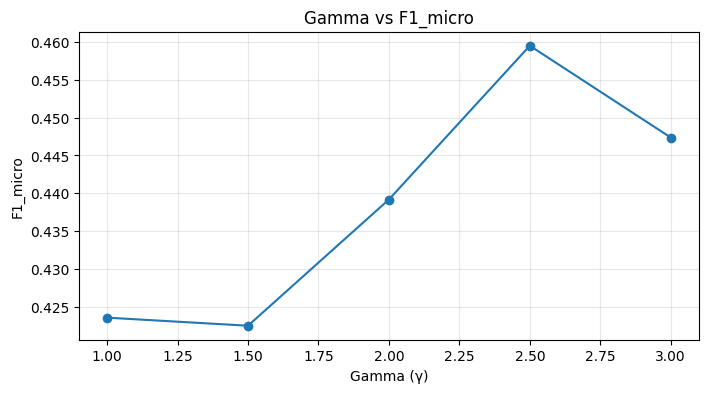

In [ ]:
# # Gamma plot

# plt.figure(figsize=(8, 4))
# plt.plot(list(results.keys()), list(results.values()), marker='o')
# plt.title("Gamma vs F1_micro")
# plt.xlabel("Gamma (γ)")
# plt.ylabel("F1_micro")
# plt.grid(alpha=0.3)
# plt.show()

### Main training loop

In [20]:
# Federated history setup

history = {
    "local_loss": {0: [], 1: [], 2: []},
    "global_loss": [],
    "global_metrics": []
}

max_auc_macro = 0.0
max_f1_micro = 0.0

In [ ]:
# Federated training loop 

config["rounds"] = 100  # important for testing time
target_evals = 100
eval_interval = max(1, round(config["rounds"] / target_evals))

# Optional: Initialize SCAFFOLD controller if selected
scaffold_ctrl = None
if config.get("algorithm", "FedAvg") == "SCAFFOLD":
    scaffold_ctrl = ScaffoldController(Global_Model)
    for cid in range(len(c_loaders)):
        scaffold_ctrl.init_client(cid, Global_Model)

for rnd in tqdm(range(config["rounds"]), colour="blue"):
    client_params = []
    total_local_loss = 0.0  # for averaging client losses

    # ---- Local training on each client ----
    for c_idx, loader in enumerate(c_loaders):
        client.load_state_dict(Global_Model.state_dict())

        local_loss, c_param = client_update(
            model=client,
            train_loader=loader,
            epochs=config["epochs"],
            lr=config["lr"],
            device=device,
            # algorithm selection
            global_model=Global_Model if config["algorithm"] in ["FedProx", "SCAFFOLD"] else None,
            use_fedprox=(config["algorithm"] == "FedProx"),
            mu=config.get("mu", 0.01),
            scaffold_ctrl=scaffold_ctrl if config["algorithm"] == "SCAFFOLD" else None,
            client_id=c_idx if config["algorithm"] == "SCAFFOLD" else None,
            use_focal=config["use_focal"]
        )

        client_params.append(c_param)
        history["local_loss"][c_idx].append(local_loss)
        total_local_loss += local_loss

    avg_local_loss = total_local_loss / len(c_loaders)

    # ---- Aggregation step (FedAvg base) ----
    new_param = FedAvg(Global_Model.state_dict(), client_params)
    Global_Model.load_state_dict(new_param)

    # ---- Update control variates (SCAFFOLD only) ----
    if config["algorithm"] == "SCAFFOLD":
        delta_cs = [scaffold_ctrl.c_local[cid] for cid in range(len(c_loaders))]
        for key in scaffold_ctrl.c_global.keys():
            scaffold_ctrl.c_global[key] = torch.mean(
                torch.stack([d[key] for d in delta_cs]), dim=0
            )

    # ---- Evaluation phase (same as centralized) ----
    if (rnd + 1) % eval_interval == 0 or rnd == config["rounds"] - 1:
        _, per_label_thr = find_best_thresholds_per_label(Global_Model, val_loader, device)
        g_loss, metrics = eval_model(
            Global_Model, device, val_loader,
            per_label_thr=per_label_thr,
            use_focal=config["use_focal"],
            alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device), 
            gamma=config["gamma"]
        )

        history["global_loss"].append(g_loss)
        history["global_metrics"].append(metrics)

        # ---- Save checkpoints ----
        save_json(history, "../History/logs/metric_history.json")
        torch.save(Global_Model.state_dict(), "../History/logs/latest_model.pt")

        # Track best-performing models
        if metrics["auc_macro"] > max_auc_macro:
            max_auc_macro = metrics["auc_macro"]
            torch.save(Global_Model.state_dict(), "../History/logs/max_auc.pt")

        if metrics["f1_micro"] > max_f1_micro:
            max_f1_micro = metrics["f1_micro"]
            torch.save(Global_Model.state_dict(), "../History/logs/max_f1_micro.pt")

        # Print progress (unchanged)
        thr_display = metrics["best_thr"] if isinstance(metrics["best_thr"], str) else f"{metrics['best_thr']:.2f}"
        print(f"Round {rnd+1}/{config['rounds']} | "
              f"Avg Local Loss: {avg_local_loss:.4f} | "
              f"Global Val Loss: {g_loss:.4f} | "
              f"F1_micro: {metrics['f1_micro']:.4f} | "
              f"Best_F1: {metrics['best_f1_micro']:.4f} (thr={thr_display})")

print("Federated training complete!")

best_f1, best_thr = find_best_threshold(Global_Model, val_loader, device)
print(f"Best threshold on validation set: {best_thr} (F1={best_f1:.4f})")


  0%|          | 0/100 [00:00<?, ?it/s]

[Per-Label Thresholds] Macro F1=0.2560
[Eval Debug] Logit range: -1.34 to 2.31 | Sigmoid mean=0.506, std=0.070
[Eval] Avg loss=0.7005 | F1_micro=0.2678 | Best_F1=0.2678 @ thr=per-label | Avg labels/sample=26.61


  1%|          | 1/100 [00:11<19:33, 11.85s/it]

Round 1/100 | Avg Local Loss: 1.2307 | Global Val Loss: 0.7005 | F1_micro: 0.2678 | Best_F1: 0.2678 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.3149
[Eval Debug] Logit range: -3.48 to 2.41 | Sigmoid mean=0.463, std=0.135
[Eval] Avg loss=0.6260 | F1_micro=0.3177 | Best_F1=0.3177 @ thr=per-label | Avg labels/sample=18.04


  2%|▏         | 2/100 [00:23<18:53, 11.56s/it]

...

 99%|█████████▉| 99/100 [19:11<00:11, 11.74s/it]

Round 99/100 | Avg Local Loss: 0.8481 | Global Val Loss: 0.4067 | F1_micro: 0.5427 | Best_F1: 0.5427 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.5212
[Eval Debug] Logit range: -19.37 to 13.84 | Sigmoid mean=0.282, std=0.325
[Eval] Avg loss=0.4124 | F1_micro=0.5553 | Best_F1=0.5553 @ thr=per-label | Avg labels/sample=8.22


100%|██████████| 100/100 [19:23<00:00, 11.63s/it]

Round 100/100 | Avg Local Loss: 0.7182 | Global Val Loss: 0.4124 | F1_micro: 0.5553 | Best_F1: 0.5553 (thr=per-label)
Federated training complete!


Best threshold on validation set: 0.3 (F1=0.4294)


### Federated Training Results Visualization

This section loads the saved federated training history (`metric_history.json`) and visualizes:

1. **Global Loss** progression across rounds.  
2. **Local Client Losses** for each client.  
3. **Validation Metrics** (AUC, F1, etc.) of the global model over time.

The plots help assess:
- Training stability across clients  
- Convergence of global loss  
- Improvements in evaluation metrics

In [22]:
# Load training history

history = load_json(filepath="../History/logs/metric_history.json")
print(f"Total Global Rounds Logged: {len(history['global_loss'])}")

Total Global Rounds Logged: 100


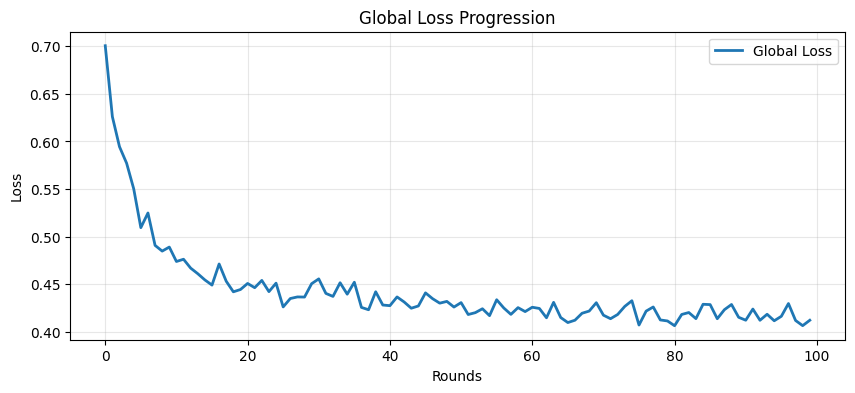

In [23]:
#Global loss progression 

plt.figure(figsize=(10, 4))
plt.plot(history["global_loss"], label="Global Loss", linewidth=2)
plt.title("Global Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

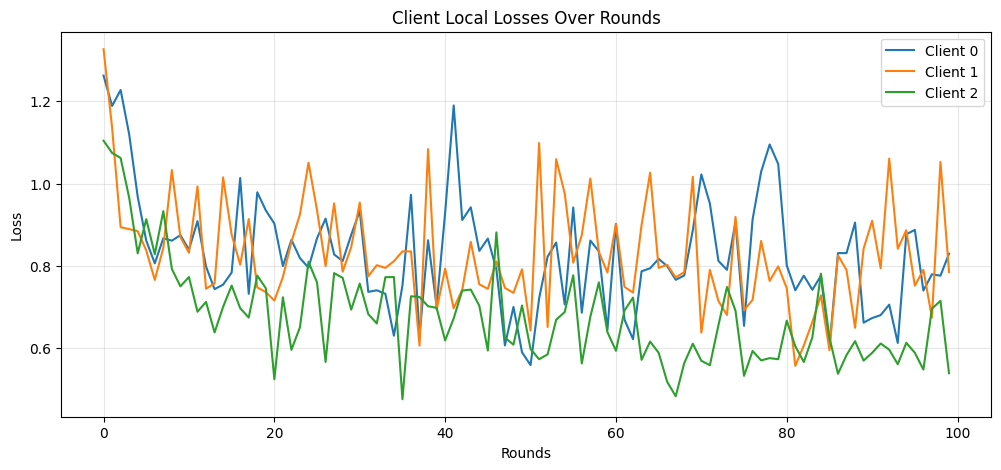

In [24]:
# Client local losses

plt.figure(figsize=(12, 5))
for c_idx in range(3):
    plt.plot(history["local_loss"][str(c_idx)], label=f"Client {c_idx}")
plt.title("Client Local Losses Over Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

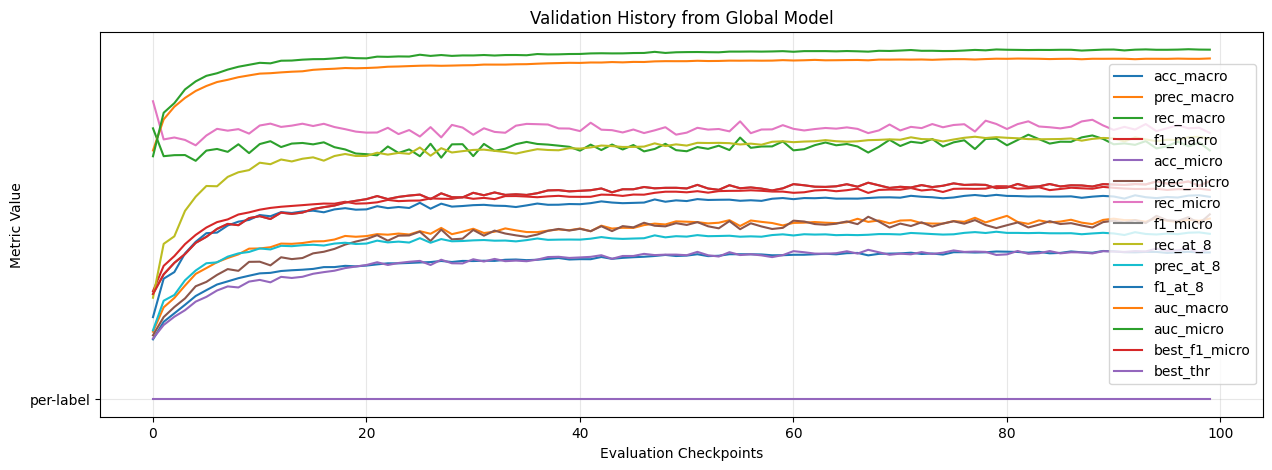

In [25]:
# Global validation metric overview

plt.figure(figsize=(15, 5))
plt.title("Validation History from Global Model")

# Plot each metric individually
for key in history["global_metrics"][0].keys():
    plt.plot([v[key] for v in history["global_metrics"]], label=key)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

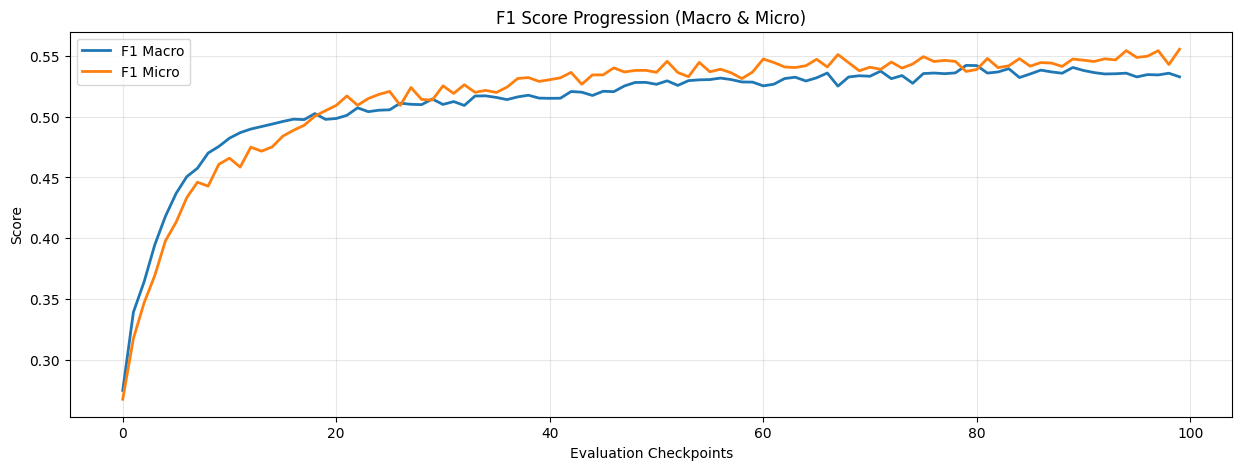

In [26]:
# F1 Score trends

plt.figure(figsize=(15, 5))
plt.title("F1 Score Progression (Macro & Micro)")
plt.plot([v["f1_macro"] for v in history["global_metrics"]], label="F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in history["global_metrics"]], label="F1 Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


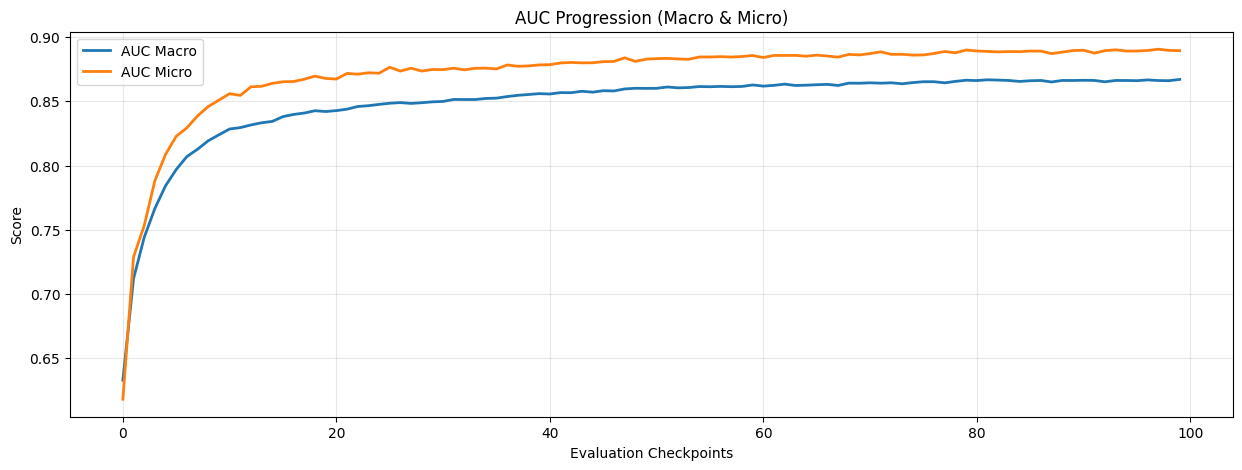

In [27]:
# AUC trends 

plt.figure(figsize=(15, 5))
plt.title("AUC Progression (Macro & Micro)")
plt.plot([v["auc_macro"] for v in history["global_metrics"]], label="AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in history["global_metrics"]], label="AUC Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Centralized Training (Baseline)

This section trains a **single centralized model** on all data combined,
using the **same configuration, metrics, and visualization pipeline** as the federated setup.

The centralized model acts as an upper performance bound for comparison.

In [28]:
# Config - same as FL

central_config = config.copy()  # same parameters as FL
print(central_config)

{'batch_size': 32, 'lr': 0.002, 'n_filters': 21, 'window_size': 6, 'epochs': 3, 'rounds': 100, 'use_focal': False, 'gamma': 2.5}


In [29]:
# Centralized model initialization

central_model = GenerateModel(
    table_path=os.path.join("..", "Model", "processed_full.w2v"),
    num_of_filters=central_config["n_filters"],
    kernel_size=central_config["window_size"]
)

central_model.to(device)
val_loader = load_data(split="val")
train_loader = load_data(split="train")

# ---- Optional but recommended: bias init for fairness ----
n_labels = val_loader.dataset[0][1].shape[0]
pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

with torch.no_grad():
    p = pos_weight / (pos_weight + 1.0)
    prior_logit = torch.log(p / (1 - p))
    central_model.final.bias.copy_(prior_logit.clamp(-10, 10))

print("Centralized model and data ready.")


Centralized model and data ready.


In [30]:
# Centralized training history set up

central_history = {
    "train_loss": [],
    "val_loss": [],
    "metrics": []
}

cent_max_auc_macro = 0.0
cent_max_f1_micro = 0.0

In [31]:
# Centralized Training Loop

# ---- Initialize optimizer and loss ----
optimizer = torch.optim.Adam(central_model.parameters(), lr=central_config["lr"], betas=(0.9, 0.99))
if central_config.get("use_focal", False):
    # Smooth alpha to prevent excessive weighting of rare labels
    alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
    loss_fn = FocalLoss(alpha=alpha, gamma=central_config.get("gamma", 2.0))
else:
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ---- Centralized training loop ----
central_config["rounds"] = 100
target_evals = 100
eval_interval = max(1, round(central_config["rounds"] / target_evals))

for rnd in tqdm(range(central_config["rounds"]), colour="green"):
    central_model.train()
    total_loss = 0.0

    # ---- Training phase ----
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds, _ = central_model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    central_history["train_loss"].append(avg_train_loss)

    # ---- Evaluation + saving ----
    if (rnd + 1) % eval_interval == 0 or rnd == central_config["rounds"] - 1:
        # Evaluate model global
        # val_loss, metrics = eval_model(central_model, device, val_loader)

        #Evaluate model per label thresh
        # Compute per-label thresholds dynamically for this checkpoint
        _, per_label_thr = find_best_thresholds_per_label(central_model, val_loader, device)
        val_loss, metrics = eval_model(
            central_model, device, val_loader,
            per_label_thr=per_label_thr,
            use_focal=central_config["use_focal"],
            alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
            gamma=central_config["gamma"]
        )

        central_history["val_loss"].append(val_loss)
        central_history["metrics"].append(metrics)

        # Save checkpoints and logs
        save_json(central_history, "../History/logs/central_metric_history.json")
        torch.save(central_model.state_dict(), "../History/logs/latest_central_model.pt")

        # Track best-performing centralized models
        if metrics["auc_macro"] > cent_max_auc_macro:
            cent_max_auc_macro = metrics["auc_macro"]
            torch.save(central_model.state_dict(), "../History/logs/max_central_auc.pt")

        if metrics["f1_micro"] > cent_max_f1_micro:
            cent_max_f1_micro = metrics["f1_micro"]
            torch.save(central_model.state_dict(), "../History/logs/max_central_f1.pt")

        # Print progress
        thr_display = metrics["best_thr"] if isinstance(metrics["best_thr"], str) else f"{metrics['best_thr']:.2f}"
        print(f"Round {rnd+1}/{central_config['rounds']} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"F1_micro: {metrics['f1_micro']:.4f} | "
            f"Best_F1: {metrics['best_f1_micro']:.4f} (thr={thr_display})")

print("Centralized training complete!")

best_f1, best_thr = find_best_threshold(central_model, val_loader, device)
print(f"Best threshold on validation set: {best_thr} (F1={best_f1:.4f})")


  0%|          | 0/100 [00:00<?, ?it/s]

[Per-Label Thresholds] Macro F1=0.2663
[Eval Debug] Logit range: -1.51 to 1.90 | Sigmoid mean=0.494, std=0.070
[Eval] Avg loss=0.6803 | F1_micro=0.2659 | Best_F1=0.2659 @ thr=per-label | Avg labels/sample=25.06


  1%|          | 1/100 [00:04<07:48,  4.73s/it]

Round 1/100 | Train Loss: 1.3880 | Val Loss: 0.6803 | F1_micro: 0.2659 | Best_F1: 0.2659 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.3306
[Eval Debug] Logit range: -4.58 to 3.02 | Sigmoid mean=0.465, std=0.158
[Eval] Avg loss=0.6289 | F1_micro=0.3276 | Best_F1=0.3276 @ thr=per-label | Avg labels/sample=18.98


  2%|▏         | 2/100 [00:09<07:45,  4.75s/it]

...

 99%|█████████▉| 99/100 [07:58<00:04,  4.82s/it]

Round 99/100 | Train Loss: 0.6393 | Val Loss: 0.3973 | F1_micro: 0.6104 | Best_F1: 0.6104 (thr=per-label)
[Per-Label Thresholds] Macro F1=0.5780
[Eval Debug] Logit range: -20.43 to 12.56 | Sigmoid mean=0.288, std=0.328
[Eval] Avg loss=0.3969 | F1_micro=0.6104 | Best_F1=0.6104 @ thr=per-label | Avg labels/sample=8.01


100%|██████████| 100/100 [08:03<00:00,  4.84s/it]

Round 100/100 | Train Loss: 0.6388 | Val Loss: 0.3969 | F1_micro: 0.6104 | Best_F1: 0.6104 (thr=per-label)
Centralized training complete!


Best threshold on validation set: 0.3 (F1=0.4482)


### Centralized Training Results Visualization

Plots below mirror the federated section for one-to-one comparison:
1. Training & validation loss  
2. Validation metrics overview  
3. F1 score trends  
4. AUC trends


In [32]:
# Load centralized history

central_history = load_json(filepath="../History/logs/central_metric_history.json")
print(f"Total Rounds Logged: {len(central_history['val_loss'])}")

Total Rounds Logged: 100


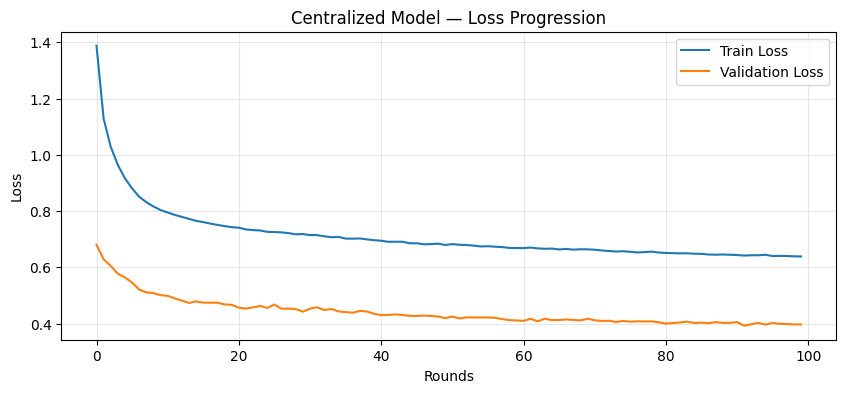

In [33]:
# Train and validation loss

plt.figure(figsize=(10, 4))
plt.plot(central_history["train_loss"], label="Train Loss")
plt.plot(central_history["val_loss"], label="Validation Loss")
plt.title("Centralized Model — Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)
    preds, _ = model(X_batch)
    print("Pred shape:", preds.shape)
    print("Label shape:", y_batch.shape)
    print("Unique label values:", torch.unique(y_batch))
    break

Pred shape: torch.Size([32, 50])
Label shape: torch.Size([32, 50])
Unique label values: tensor([0., 1.], device='cuda:0', dtype=torch.float64)


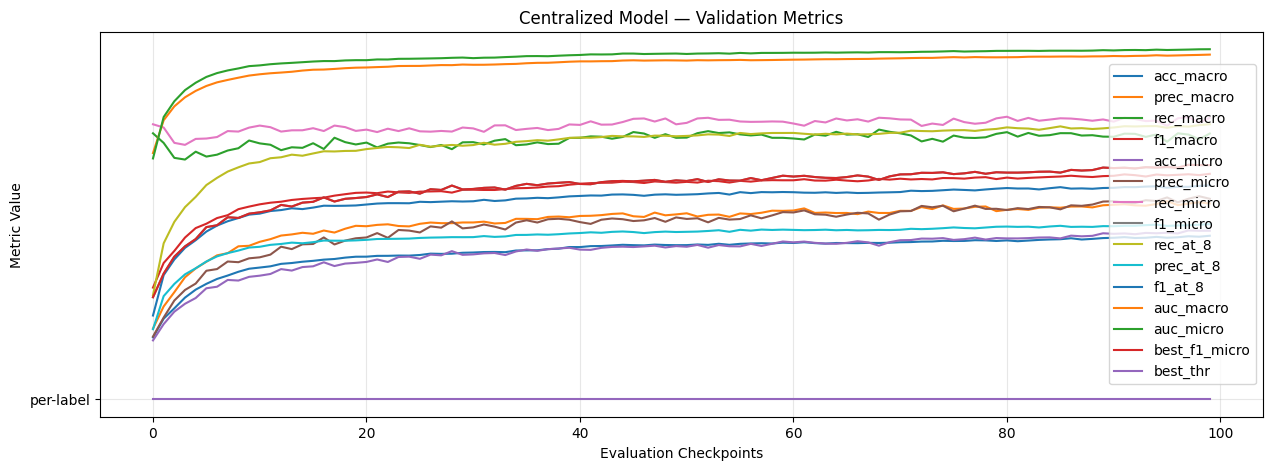

In [35]:
# Validaton Metrics Overview

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — Validation Metrics")

for key in central_history["metrics"][0].keys():
    plt.plot([v[key] for v in central_history["metrics"]], label=key)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

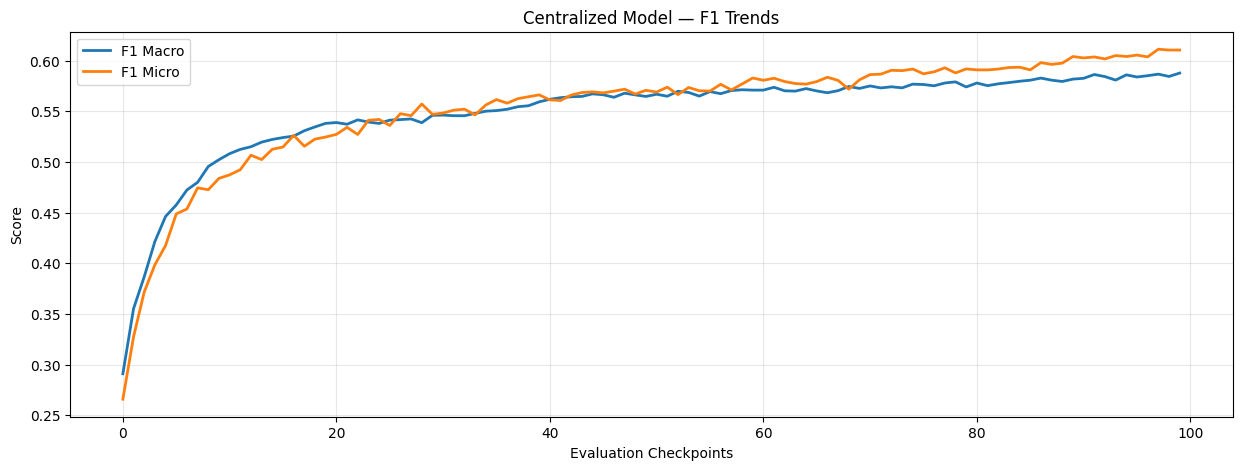

In [36]:
# F1 Score Trends

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — F1 Trends")
plt.plot([v["f1_macro"] for v in central_history["metrics"]], label="F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in central_history["metrics"]], label="F1 Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

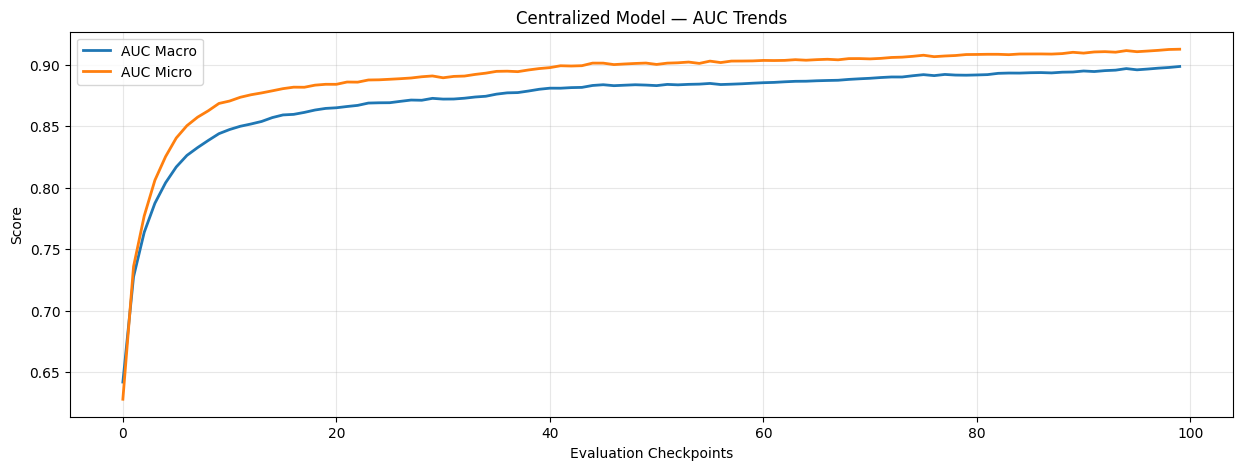

In [37]:
# AUC trends

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — AUC Trends")
plt.plot([v["auc_macro"] for v in central_history["metrics"]], label="AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in central_history["metrics"]], label="AUC Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Federated vs Centralized Comparison

This section compares the **Federated Learning (FL)** and **Centralized Training (CL)** experiments:

- Overlayed loss curves
- Validation metric trends
- Best-performing metrics summary (F1, AUC, etc.)

The goal is to analyze the trade-offs between distributed vs. centralized optimization.


In [38]:
# Load Both Training Histories

fed_history = load_json(filepath="../History/logs/metric_history.json")
central_history = load_json(filepath="../History/logs/central_metric_history.json")

print(f"FL rounds logged: {len(fed_history['global_loss'])}")
print(f"CL rounds logged: {len(central_history['val_loss'])}")


FL rounds logged: 100
CL rounds logged: 100


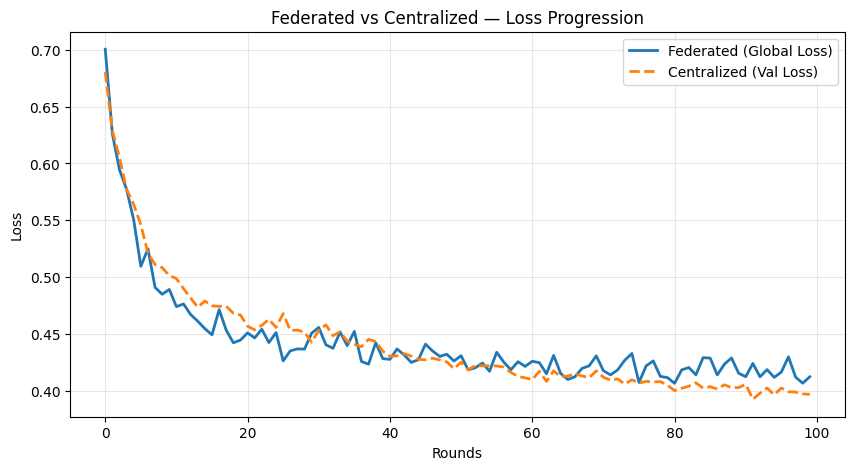

In [39]:
# FL vs Certralized - Loss Comparison

plt.figure(figsize=(10, 5))
plt.plot(fed_history["global_loss"], label="Federated (Global Loss)", linewidth=2)
plt.plot(central_history["val_loss"], label="Centralized (Val Loss)", linewidth=2, linestyle="--")
plt.title("Federated vs Centralized — Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


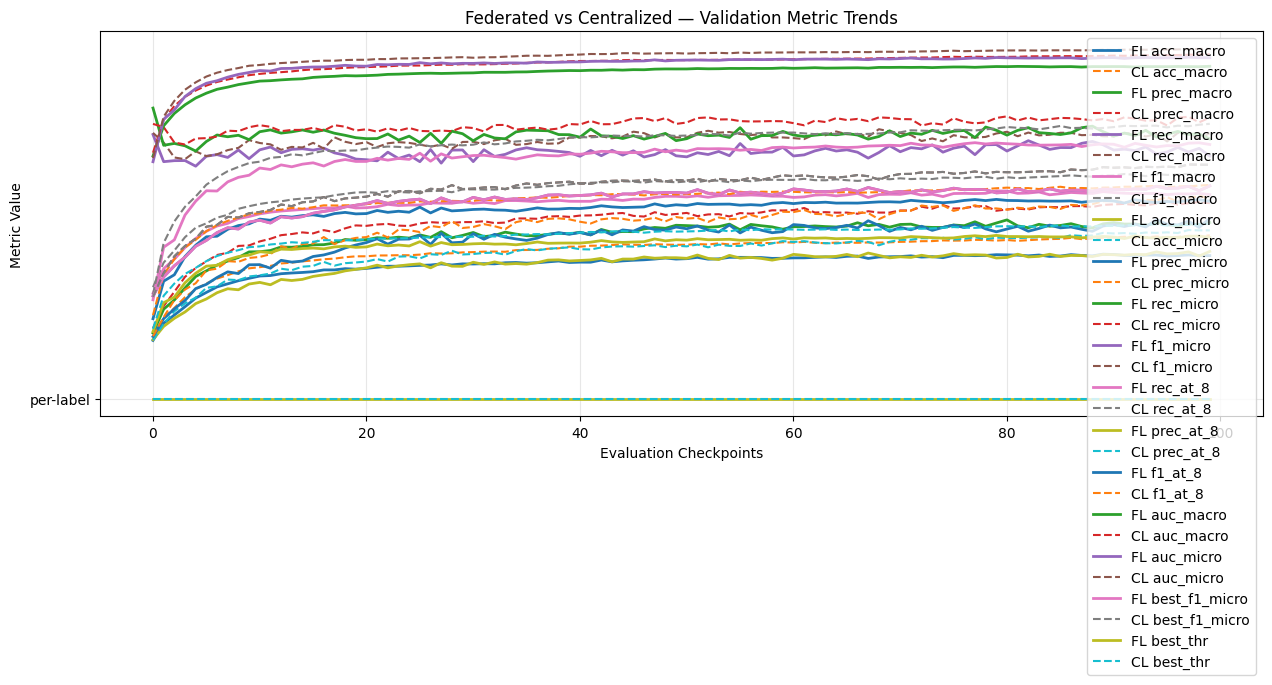

In [40]:

# Federated vs Centralized — Validation Metric Trends

plt.figure(figsize=(15, 5))
plt.title("Federated vs Centralized — Validation Metric Trends")

fed_keys = fed_history["global_metrics"][0].keys()
cent_keys = central_history["metrics"][0].keys()

# Only plot overlapping metrics
shared_metrics = [k for k in fed_keys if k in cent_keys]

for key in shared_metrics:
    plt.plot([m[key] for m in fed_history["global_metrics"]],
             label=f"FL {key}", linewidth=2)
    plt.plot([m[key] for m in central_history["metrics"]],
             label=f"CL {key}", linestyle="--")

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


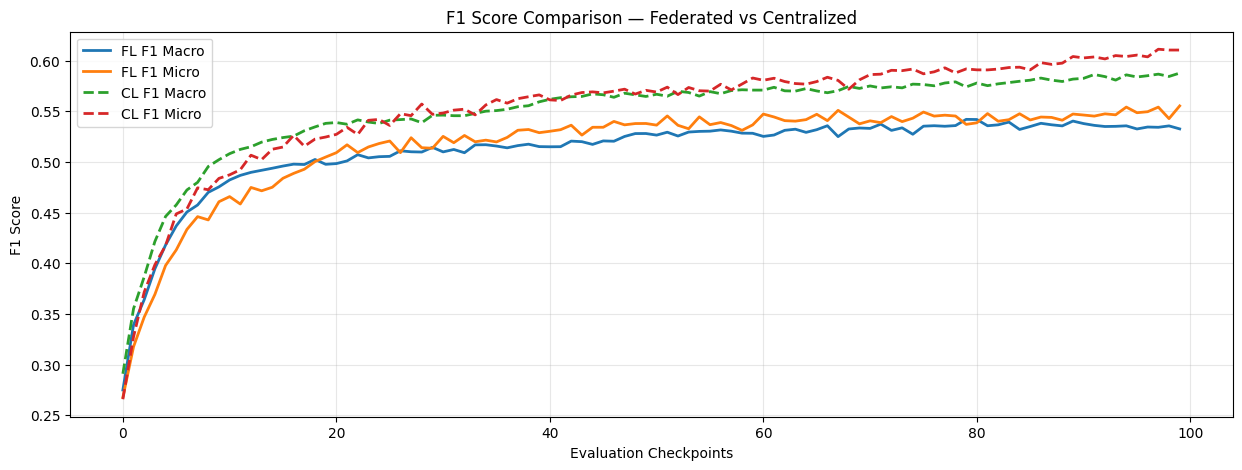

In [41]:
# F1 Comparison (Macro & Micro)

plt.figure(figsize=(15, 5))
plt.title("F1 Score Comparison — Federated vs Centralized")

plt.plot([v["f1_macro"] for v in fed_history["global_metrics"]], label="FL F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in fed_history["global_metrics"]], label="FL F1 Micro", linewidth=2)
plt.plot([v["f1_macro"] for v in central_history["metrics"]], label="CL F1 Macro", linestyle="--", linewidth=2)
plt.plot([v["f1_micro"] for v in central_history["metrics"]], label="CL F1 Micro", linestyle="--", linewidth=2)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

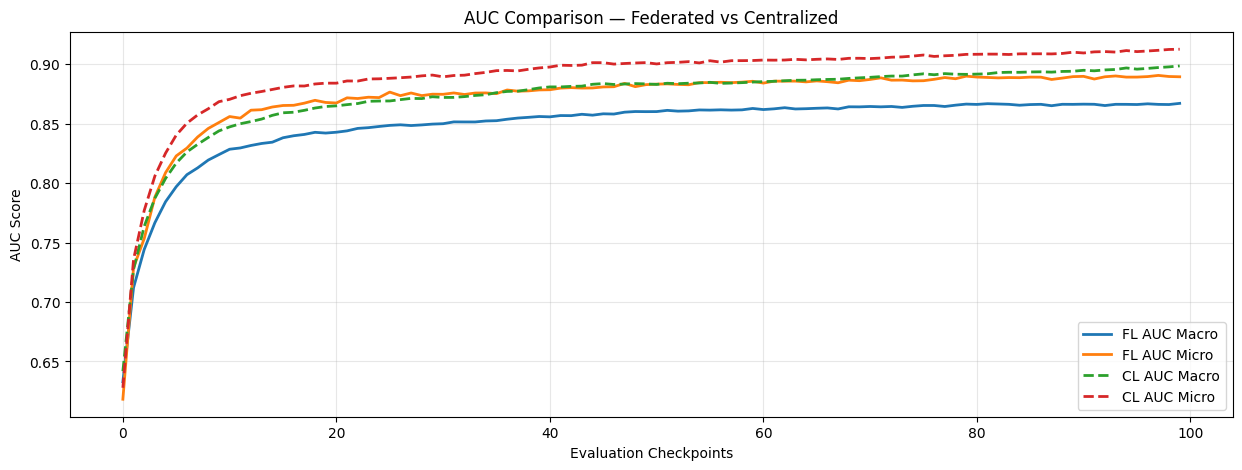

In [42]:
# AUC Comparison (Macro & Micro)

plt.figure(figsize=(15, 5))
plt.title("AUC Comparison — Federated vs Centralized")

plt.plot([v["auc_macro"] for v in fed_history["global_metrics"]], label="FL AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in fed_history["global_metrics"]], label="FL AUC Micro", linewidth=2)
plt.plot([v["auc_macro"] for v in central_history["metrics"]], label="CL AUC Macro", linestyle="--", linewidth=2)
plt.plot([v["auc_micro"] for v in central_history["metrics"]], label="CL AUC Micro", linestyle="--", linewidth=2)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [43]:
# Quantitative Comparison — Best Scores

fed_best_f1 = max([m["f1_micro"] for m in fed_history["global_metrics"]])
fed_best_auc = max([m["auc_macro"] for m in fed_history["global_metrics"]])

cent_best_f1 = max([m["f1_micro"] for m in central_history["metrics"]])
cent_best_auc = max([m["auc_macro"] for m in central_history["metrics"]])

print("Federated vs Centralized Results Summary")
print(f"Federated  → Best F1 (micro): {fed_best_f1:.4f} | Best AUC (macro): {fed_best_auc:.4f}")
print(f"Centralized → Best F1 (micro): {cent_best_f1:.4f} | Best AUC (macro): {cent_best_auc:.4f}")


Federated vs Centralized Results Summary
Federated  → Best F1 (micro): 0.5553 | Best AUC (macro): 0.8671
Centralized → Best F1 (micro): 0.6112 | Best AUC (macro): 0.8986


## Metric Stuff

In [44]:
print(history["global_metrics"][-3:])
print(central_history["metrics"][-3:])

[{'acc_macro': 0.37519272064675535, 'prec_macro': 0.4566277910595187, 'rec_macro': 0.6435052722704709, 'f1_macro': 0.5341942730501864, 'acc_micro': 0.38323570263904827, 'prec_micro': 0.4632116788321168, 'rec_micro': 0.6894079304725692, 'f1_micro': 0.5541148220912465, 'rec_at_8': 0.6665400841341679, 'prec_at_8': 0.4236670799752015, 'f1_at_8': 0.5180503310345493, 'auc_macro': 0.8662115513295043, 'auc_micro': 0.8905716901842613, 'best_f1_micro': 0.5541148220912465, 'best_thr': 'per-label'}, {'acc_macro': 0.3734119226658272, 'prec_macro': 0.4539074779044542, 'rec_macro': 0.6531399404101329, 'f1_macro': 0.5355960334952574, 'acc_micro': 0.3724376244582406, 'prec_micro': 0.44693561990441383, 'rec_micro': 0.69082020640956, 'f1_micro': 0.5427388725301925, 'rec_at_8': 0.6676210985668154, 'prec_at_8': 0.4245195288282703, 'f1_at_8': 0.5190141032943537, 'auc_macro': 0.8660840792478439, 'auc_micro': 0.8896621518495613, 'best_f1_micro': 0.5427388725301925, 'best_thr': 'per-label'}, {'acc_macro': 0.37

[Per-Label Thresholds] Macro F1=0.5780
[Eval Debug] Logit range: -20.43 to 12.56 | Sigmoid mean=0.288, std=0.328


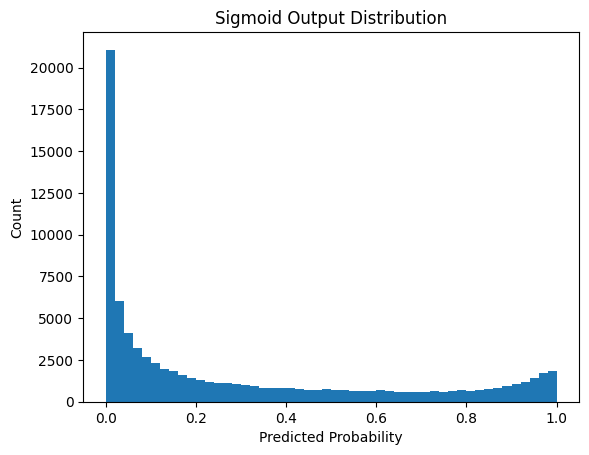

[Eval] Avg loss=0.3969 | F1_micro=0.6104 | Best_F1=0.6104 @ thr=per-label | Avg labels/sample=8.01


In [45]:
macro_f1, per_label_thr = find_best_thresholds_per_label(central_model, val_loader, device)
val_loss, metrics = eval_model(
    central_model,
    device,
    val_loader,
    per_label_thr=per_label_thr,
    sigmoid=True,
    use_focal=central_config["use_focal"],
    alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
    gamma=central_config["gamma"]
)

Per-label thresholds:
 tensor([0.8500, 0.9000, 0.7000, 0.8000, 0.7500, 0.8000, 0.8000, 0.8000, 0.4500,
        0.7500, 0.7500, 0.7000, 0.7000, 0.8500, 0.8500, 0.9000, 0.6500, 0.5500,
        0.9000, 0.8000, 0.4500, 0.8500, 0.9000, 0.9000, 0.7500, 0.9000, 0.6500,
        0.6500, 0.9000, 0.8000, 0.8500, 0.8500, 0.8500, 0.8000, 0.7000, 0.6500,
        0.9000, 0.8500, 0.9000, 0.8500, 0.7000, 0.6500, 0.6500, 0.9000, 0.6000,
        0.8500, 0.8500, 0.7000, 0.9000, 0.9000])
Min threshold: 0.450
Max threshold: 0.900
Mean threshold: 0.778
Std dev: 0.117


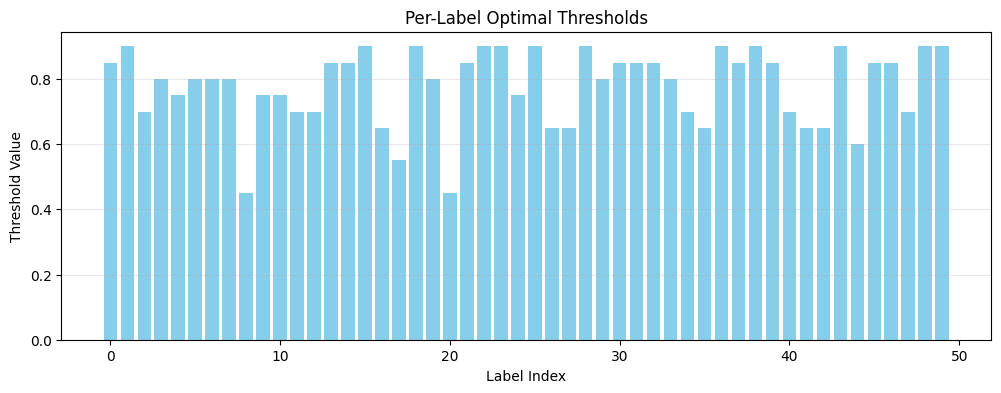

In [46]:
print("Per-label thresholds:\n", per_label_thr)
print(f"Min threshold: {per_label_thr.min():.3f}")
print(f"Max threshold: {per_label_thr.max():.3f}")
print(f"Mean threshold: {per_label_thr.mean():.3f}")
print(f"Std dev: {per_label_thr.std():.3f}")

torch.save(per_label_thr, "../History/logs/per_label_thresholds.pt")

plt.figure(figsize=(12, 4))
plt.bar(np.arange(len(per_label_thr)), per_label_thr.cpu().numpy(), color='skyblue')
plt.title("Per-Label Optimal Thresholds")
plt.xlabel("Label Index")
plt.ylabel("Threshold Value")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [47]:
macro_f1_global, _ = find_best_threshold(central_model, val_loader, device)
macro_f1_per_label, _ = find_best_thresholds_per_label(central_model, val_loader, device)

print(f"Global tuned F1: {macro_f1_global:.4f}")
print(f"Per-label tuned F1: {macro_f1_per_label:.4f}")

[Per-Label Thresholds] Macro F1=0.5780
Global tuned F1: 0.4482
Per-label tuned F1: 0.5780


## Test Set Comparison

In [48]:
# --- Test set evaluation (for paper comparison) ---
test_loader = load_data(split="test")

# Load best-performing models (by val F1 or AUC)
central_model.load_state_dict(torch.load("../History/logs/max_central_f1.pt"))
Global_Model.load_state_dict(torch.load("../History/logs/max_f1_micro.pt"))

# Compute per-label thresholds from validation set (to keep protocol consistent)
_, per_label_thr = find_best_thresholds_per_label(central_model, val_loader, device)

# ---- Centralized Test Evaluation ----
test_loss_c, test_metrics_c = eval_model(
    central_model,
    device,
    test_loader,
    per_label_thr=per_label_thr,
    use_focal=central_config["use_focal"],
    alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
    gamma=central_config["gamma"]
)
print(f"Centralized Test — F1_micro={test_metrics_c['f1_micro']:.3f}, "
      f"F1_macro={test_metrics_c['f1_macro']:.3f}, "
      f"AUC_micro={test_metrics_c['auc_micro']:.3f}, "
      f"AUC_macro={test_metrics_c['auc_macro']:.3f}")

# ---- Federated Test Evaluation ----
test_loss_f, test_metrics_f = eval_model(
    Global_Model,
    device,
    test_loader,
    per_label_thr=per_label_thr,
    use_focal=config["use_focal"],
    alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
    gamma=config["gamma"]
)
print(f"Federated Test — F1_micro={test_metrics_f['f1_micro']:.3f}, "
      f"F1_macro={test_metrics_f['f1_macro']:.3f}, "
      f"AUC_micro={test_metrics_f['auc_micro']:.3f}, "
      f"AUC_macro={test_metrics_f['auc_macro']:.3f}")


[Per-Label Thresholds] Macro F1=0.5767
[Eval Debug] Logit range: -17.05 to 10.50 | Sigmoid mean=0.296, std=0.329
[Eval] Avg loss=0.3970 | F1_micro=0.6121 | Best_F1=0.6121 @ thr=per-label | Avg labels/sample=8.20
Centralized Test — F1_micro=0.612, F1_macro=0.599, AUC_micro=0.912, AUC_macro=0.895
[Eval Debug] Logit range: -18.02 to 11.12 | Sigmoid mean=0.295, std=0.326
[Eval] Avg loss=0.4295 | F1_micro=0.5438 | Best_F1=0.5438 @ thr=per-label | Avg labels/sample=8.08
Federated Test — F1_micro=0.544, F1_macro=0.543, AUC_micro=0.882, AUC_macro=0.857


In [ ]:
## Fed Loop

import time
import pandas as pd

results_path = "../History/results_summary.csv"
results = []

for algo in ["FedAvg", "FedProx", "SCAFFOLD"]:
    for num_clients in [2, 3, 4]:
        for local_epochs in [1, 2, 3]:
            print(f"\n=== Running {algo} | Clients={num_clients} | Local Epochs={local_epochs} ===")

            # --- 1. Configure ---
            config["algorithm"] = algo
            config["epochs"] = local_epochs

            # --- 2. Partition data ---
            if num_clients == 2:
                c1, c2 = random_split(train_dataset, lengths=[0.5, 0.5])
                c_loaders = [DataLoader(c, batch_size=config["batch_size"], shuffle=True) for c in [c1, c2]]
            elif num_clients == 3:
                c1, c2, c3 = random_split(train_dataset, lengths=[0.33, 0.33, 0.34])
                c_loaders = [DataLoader(c, batch_size=config["batch_size"], shuffle=True) for c in [c1, c2, c3]]
            elif num_clients == 4:
                c1, c2, c3, c4 = random_split(train_dataset, lengths=[0.25]*4)
                c_loaders = [DataLoader(c, batch_size=config["batch_size"], shuffle=True) for c in [c1, c2, c3, c4]]

            # --- 3. Re-initialize models ---
            Global_Model = GenerateModel(
                table_path=model_param_path,
                num_of_filters=config["n_filters"],
                kernel_size=config["window_size"]
            ).to(device)

            client = GenerateModel(
                table_path=model_param_path,
                num_of_filters=config["n_filters"],
                kernel_size=config["window_size"]
            ).to(device)

            # ---- Bias init ----
            with torch.no_grad():
                p = pos_weight / (pos_weight + 1.0)
                prior_logit = torch.log(p / (1 - p))
                Global_Model.final.bias.copy_(prior_logit.clamp(-10, 10))
                client.final.bias.copy_(prior_logit.clamp(-10, 10))

            # --- 4. Run training ---
            start_time = time.time()

            scaffold_ctrl = None
            if config["algorithm"] == "SCAFFOLD":
                scaffold_ctrl = ScaffoldController(Global_Model)
                for cid in range(len(c_loaders)):
                    scaffold_ctrl.init_client(cid, Global_Model)

            history = {"local_loss": {cid: [] for cid in range(len(c_loaders))},
                       "global_loss": [], "global_metrics": []}
            max_auc_macro = 0.0
            max_f1_micro = 0.0

            for rnd in tqdm(range(config["rounds"]), colour="blue", leave=False):
                client_params = []
                total_local_loss = 0.0
                for c_idx, loader in enumerate(c_loaders):
                    client.load_state_dict(Global_Model.state_dict())
                    local_loss, c_param = client_update(
                        model=client,
                        train_loader=loader,
                        epochs=config["epochs"],
                        lr=config["lr"],
                        device=device,
                        global_model=Global_Model if config["algorithm"] in ["FedProx", "SCAFFOLD"] else None,
                        use_fedprox=(config["algorithm"] == "FedProx"),
                        mu=config.get("mu", 0.01),
                        scaffold_ctrl=scaffold_ctrl if config["algorithm"] == "SCAFFOLD" else None,
                        client_id=c_idx if config["algorithm"] == "SCAFFOLD" else None,
                        use_focal=config["use_focal"]
                    )
                    client_params.append(c_param)
                    total_local_loss += local_loss

                avg_local_loss = total_local_loss / len(c_loaders)
                new_param = FedAvg(Global_Model.state_dict(), client_params)
                Global_Model.load_state_dict(new_param)

                # SCAFFOLD update
                if config["algorithm"] == "SCAFFOLD":
                    delta_cs = [scaffold_ctrl.c_local[cid] for cid in range(len(c_loaders))]
                    for key in scaffold_ctrl.c_global.keys():
                        scaffold_ctrl.c_global[key] = torch.mean(
                            torch.stack([d[key] for d in delta_cs]), dim=0
                        )

            train_time = round(time.time() - start_time, 2)
            print(f"Training finished in {train_time} sec")

            # --- 5. Validation thresholding ---
            _, per_label_thr = find_best_thresholds_per_label(Global_Model, val_loader, device)

            # --- 6. Evaluate on Test Set ---
            test_loss, test_metrics = eval_model(
                Global_Model, device, load_data("test"),
                per_label_thr=per_label_thr,
                use_focal=config["use_focal"],
                alpha=torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device),
                gamma=config["gamma"]
            )

            # --- 7. Record results ---
            results.append({
                "Function": algo,
                "Clients": num_clients,
                "Local Epochs": local_epochs,
                "AUC Macro": round(test_metrics.get("auc_macro", 0), 4),
                "AUC Micro": round(test_metrics.get("auc_micro", 0), 4),
                "F1 Macro": round(test_metrics.get("f1_macro", 0), 4),
                "F1 Micro": round(test_metrics.get("f1_micro", 0), 4),
                "PR-AUC Macro": round(test_metrics.get("prauc_macro", 0), 4),
                "PR-AUC Micro": round(test_metrics.get("prauc_micro", 0), 4),
                "Time": train_time
            })

            # Save interim results after each run
            pd.DataFrame(results).to_csv(results_path, index=False)

print("\n✅ All 27 configurations complete!")
print(f"Results saved to {results_path}")
